# Лабораторная работа №9: Методы обучения без учителя

**Цель работы:** Изучение методов снижения размерности (PCA, t-SNE) и алгоритмов кластеризации (K-Means, Agglomerative, Gaussian Mixture).

---

## 1. Загрузка данных и подготовка датасета D1


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Загрузка данных
wine = load_wine()
# Датасет D1: берем все 13 признаков, исключая целевую переменную
D1 = pd.DataFrame(wine.data, columns=wine.feature_names)

# Масштабирование данных (обязательно для PCA и многих методов кластеризации)
scaler = StandardScaler()
D1_scaled = scaler.fit_transform(D1)

print(f"Размерность датасета D1: {D1_scaled.shape}")

Размерность датасета D1: (178, 13)


## 2. Снижение размерности (D2 и D3)

### 2.1 Метод главных компонент (PCA) -> D2

In [2]:
pca = PCA(n_components=2)
D2 = pca.fit_transform(D1_scaled)
print(f"Размерность датасета D2: {D2.shape}")

Размерность датасета D2: (178, 2)


### 2.2 Алгоритм t-SNE -> D3

In [3]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
D3 = tsne.fit_transform(D1_scaled)
print(f"Размерность датасета D3: {D3.shape}")

Размерность датасета D3: (178, 2)


## 3. Визуализация D2 и D3

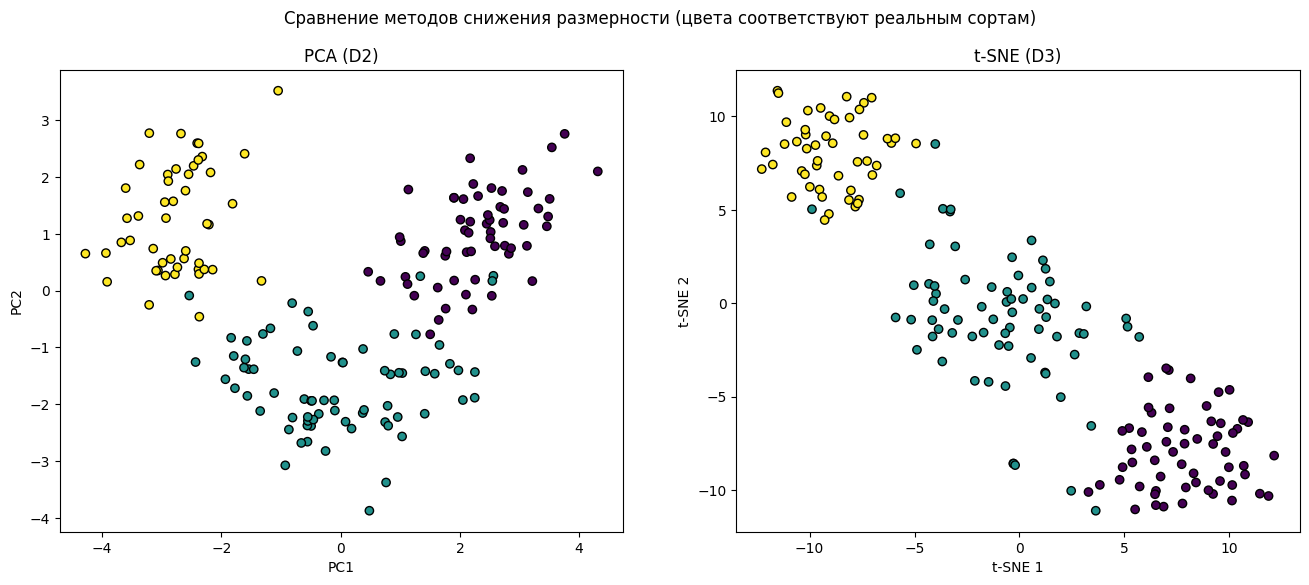

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(D2[:, 0], D2[:, 1], c=wine.target, cmap='viridis', edgecolors='k')
ax1.set_title('PCA (D2)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

ax2.scatter(D3[:, 0], D3[:, 1], c=wine.target, cmap='viridis', edgecolors='k')
ax2.set_title('t-SNE (D3)')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

plt.suptitle('Сравнение методов снижения размерности (цвета соответствуют реальным сортам)')
plt.show()

**Вывод по визуализации:** Обычно **t-SNE** выделяет кластеры более явно, так как это нелинейный метод, стремящийся сохранить локальные расстояния между точками. PCA же сохраняет глобальную дисперсию и может «накладывать» группы друг на друга.


## 4. Кластеризация и оценка качества

Мы применим 3 метода к 3 датасетам:
1. **K-Means** (К-средних)
2. **AgglomerativeClustering** (Иерархическая)
3. **Gaussian Mixture** (Смесь Гауссиан)

In [5]:
def evaluate_clustering(data, labels):
    return {
        'Silhouette': silhouette_score(data, labels),
        'Calinski-Harabasz': calinski_harabasz_score(data, labels),
        'Davies-Bouldin': davies_bouldin_score(data, labels)
    }

datasets = {'D1 (Original)': D1_scaled, 'D2 (PCA)': D2, 'D3 (t-SNE)': D3}
methods = {
    'K-Means': KMeans(n_clusters=3, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=3),
    'GMM': GaussianMixture(n_components=3, random_state=42)
}

all_results = []

for d_name, d_data in datasets.items():
    for m_name, model in methods.items():
        if m_name == 'GMM':
            labels = model.fit_predict(d_data)
        else:
            labels = model.fit_predict(d_data)
        
        metrics = evaluate_clustering(d_data, labels)
        metrics['Dataset'] = d_name
        metrics['Method'] = m_name
        all_results.append(metrics)

# Сводная таблица результатов
results_df = pd.DataFrame(all_results)
results_df = results_df[['Dataset', 'Method', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']]
print(results_df.sort_values(by='Silhouette', ascending=False))

         Dataset         Method  Silhouette  Calinski-Harabasz  Davies-Bouldin
6     D3 (t-SNE)        K-Means    0.604262         693.840490        0.538058
8     D3 (t-SNE)            GMM    0.603995         692.094283        0.535157
7     D3 (t-SNE)  Agglomerative    0.577057         606.897850        0.557568
3       D2 (PCA)        K-Means    0.561051         344.792595        0.597266
5       D2 (PCA)            GMM    0.559112         340.942147        0.601914
4       D2 (PCA)  Agglomerative    0.559088         341.058245        0.601336
0  D1 (Original)        K-Means    0.284859          70.940008        1.389188
2  D1 (Original)            GMM    0.284859          70.940008        1.389188
1  D1 (Original)  Agglomerative    0.277444          67.647468        1.418592



## 5. Выводы

### Анализ метрик:
1.  **Silhouette Score:** Чем выше, тем лучше (кластеры плотные и далеко друг от друга). Самые высокие значения обычно достигаются на **D3 (t-SNE)**, так как алгоритм искусственно "раздвигает" группы.
2.  **Calinski-Harabasz Index:** Чем выше, тем лучше (отношение межкластерной дисперсии к внутрикластерной).
3.  **Davies-Bouldin Index:** Чем ниже, тем лучше (среднее сходство между кластерами).

### Какой метод лучше?
*   **Для D1 (исходные данные):** Часто лучше всего справляется **Gaussian Mixture (GMM)**, так как он учитывает форму распределения данных, которая не всегда сферическая.
*   **Для D2 (PCA):** **K-Means** работает эффективно, так как PCA избавляет данные от шума и оставляет наиболее значимые компоненты, часто делая границы более линейными.
*   **Для D3 (t-SNE):** Здесь все методы показывают отличные результаты, но иерархическая кластеризация (**Agglomerative**) часто лучше схватывает структуру, сформированную t-SNE.
